In [1]:
####################################
#ENVIRONMENT SETUP

In [2]:
#LIBRARIES

#system
import os
import sys

#data classes
import xarray as xr



#loading bar
from tqdm import tqdm

#plotting 
import matplotlib.pyplot as plt

In [3]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [4]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "Observation_Data", "TRACER")
dataType = "RadarData"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/TRACER/RadarData



In [5]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [6]:
spinup_hours = "0"
RunType = ("TRACER","WET","NSSL",spinup_hours)

# spinup_hours = "-6"
# RunType = ("TRACER","DIURNAL","NSSL",spinup_hours)

ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           WET
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-07-01 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:193
 # Diag Files:   193
 # Time Steps:   193
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs
 Static File:    TRACER_regional5250_scaled3_

In [7]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_DataSubsetting import DataSubsetting_Class

In [8]:
########################
#CODE INFORMATION

In [9]:
#Getting Data
# https://projectpythia.org/mrms-cookbook/notebooks/ch4-realtimedata/
# Authors:
# Ty Janoski
# City College of New York and NOAA/OAR National Severe Storms Laboratory
# Mya Sears
# NSF National Center for Atmospheric Research
# Bella Condo
# University at Albany (State University of New York)
# JD Heaton
# Metropolitan State University of Denver
# MaKenna Collins
# Jackson State University
# Maxwell Grover
# Argonne National Laboratory

In [10]:
########################
#LIBRARIES

In [11]:
#system packages
import re

#data loading packages
import pandas as pd

# Packages required to request and open data from AWS S3
import s3fs
import urllib
import tempfile
import gzip

In [12]:
########################
#DATA RETRIEVAL FUNCTIONS

In [13]:
# ============================================================
# Helper: extract time from filename
# ============================================================
def extract_time_from_filename(fname):
    """Parse MRMS filename and return a pandas.Timestamp (UTC)."""
    match = re.search(r"_(\d{8}-\d{6})\.grib2\.gz", fname)
    return pd.to_datetime(match.group(1), format="%Y%m%d-%H%M%S", utc=True)

# ============================================================
# Select target times at 6-hour intervals
# ============================================================
def select_nearest_to_targets(files, interval_hours="6h"):
    """Return subset of file paths nearest to each N-hour UTC time."""
    # Extract actual timestamps from filenames
    file_times = pd.Series({f: extract_time_from_filename(f) for f in files}).sort_values()

    # Build list of desired UTC times covering file range
    start = file_times.min().floor(interval_hours)   # lowercase h
    end   = file_times.max().ceil(interval_hours)
    targets = pd.date_range(start, end, freq=interval_hours, tz="UTC")

    selected = []
    for t in targets:
        nearest_idx = (abs(file_times - t)).argmin()
        selected.append(file_times.index[nearest_idx])

    return selected

# def RetrieveMRMSRadarData_V1(ModelData, region, product, datestrings,
#                              interval_hours="6h",
#                              outputPath=""):
#     """
#     Retrieve MRMS reflectivity data and save each selected timestep
#     as an individual NetCDF file.
#     """
#     aws = s3fs.S3FileSystem(anon=True)

#     for datestring in datestrings:
#         print(f"\n=== Processing {datestring} ===")

#         # List all files for this date
#         try:
#             data_files = aws.ls(f'noaa-mrms-pds/{region}/{product}/{datestring}/')
#         except Exception as e:
#             print(f"Could not access {datestring}: {e}")
#             continue

#         if not data_files:
#             print(f"No files found for {datestring}")
#             continue

#         data_files = sorted(data_files)
#         selected_files = select_nearest_to_targets(data_files, interval_hours=interval_hours)

#         for f in tqdm(selected_files, desc=f"{datestring} files", leave=False, unit="file"):

#             try:
#                 response = urllib.request.urlopen(f"https://noaa-mrms-pds.s3.amazonaws.com/{f[14:]}")
#                 compressed_file = response.read()

#                 with tempfile.NamedTemporaryFile(suffix=".grib2") as tmp:
#                     tmp.write(gzip.decompress(compressed_file))
#                     tmp.flush()
#                     ds = xr.load_dataarray(tmp.name, engine="cfgrib", decode_timedelta=True)
#                     ds.name = product

#                     # Drop differing coords
#                     for coord in ["valid_time", "step"]:
#                         if coord in ds.coords:
#                             ds = ds.drop_vars(coord)

#                     # Attach true timestamp from filename
#                     file_time = extract_time_from_filename(f)
#                     ds = ds.expand_dims(time=[file_time])

#                     # Subset
#                     subset = DataSubsetting_Class.SubsetDataRegion(ds, ModelData)

#                     # Convert to timezone-naive time
#                     subset = subset.assign_coords(
#                         time=pd.to_datetime(subset.time.to_pandas()).tz_localize(None)
#                     )

#                     # --- Save each timestep as its own NetCDF ---
#                     time_str = file_time.strftime("%Y%m%d-%H%M%S")
#                     outputFile = f"MRMSReflectivity_{region}_{ModelData.region}_{time_str}.nc"
#                     os.makedirs(outputPath, exist_ok=True)
#                     outputFilePath = os.path.join(outputPath, outputFile)

#                     subset.to_netcdf(outputFilePath)
#                     print(f"Saved: {outputFilePath}")
 
#             except Exception as e:
#                 print(f"Failed to load {f}: {e}")
#                 continue

def RetrieveMRMSRadarData_V2(ModelData, region, product, datestrings,
                             interval_hours="6h",
                             outputPath=""):
    """
    Retrieve MRMS reflectivity data and save each selected timestep
    as an individual NetCDF file.
    """
    aws = s3fs.S3FileSystem(anon=True)

    for datestring in datestrings:
        print(f"\n=== Processing {datestring} ===")

        # List all files for this date
        try:
            data_files = aws.ls(f'noaa-mrms-pds/{region}/{product}/{datestring}/')
        except Exception as e:
            print(f"Could not access {datestring}: {e}")
            continue

        if not data_files:
            print(f"No files found for {datestring}")
            continue

        data_files = sorted(data_files)
        selected_files = select_nearest_to_targets(data_files, interval_hours=interval_hours)

        for f in tqdm(selected_files, desc=f"{datestring} files", leave=False, unit="file"):

            # ------------------------------------------------------------------
            # Build output filename BEFORE downloading anything
            # ------------------------------------------------------------------
            file_time = extract_time_from_filename(f)
            time_str = file_time.strftime("%Y%m%d-%H%M%S")

            outputFile = f"MRMSReflectivity_{region}_{ModelData.region}_{time_str}.nc"
            os.makedirs(outputPath, exist_ok=True)
            outputFilePath = os.path.join(outputPath, outputFile)

            # ------------------------------------------------------------------
            # Skip if this file already exists
            # ------------------------------------------------------------------
            if os.path.exists(outputFilePath):
                print(f"Already exists, skipping: {outputFilePath}")
                continue

            # ------------------------------------------------------------------
            # Otherwise download + process
            # ------------------------------------------------------------------
            try:
                response = urllib.request.urlopen(
                    f"https://noaa-mrms-pds.s3.amazonaws.com/{f[14:]}"
                )
                compressed_file = response.read()

                with tempfile.NamedTemporaryFile(suffix=".grib2") as tmp:
                    tmp.write(gzip.decompress(compressed_file))
                    tmp.flush()
                    ds = xr.load_dataarray(tmp.name, engine="cfgrib", decode_timedelta=True)
                    ds.name = product

                # Drop differing coords
                for coord in ["valid_time", "step"]:
                    if coord in ds.coords:
                        ds = ds.drop_vars(coord)

                # Attach true timestamp
                ds = ds.expand_dims(time=[file_time])

                # Subset to model domain
                subset = DataSubsetting_Class.SubsetDataRegion(ds, ModelData)

                # Convert to timezone-naive
                subset = subset.assign_coords(
                    time=pd.to_datetime(subset.time.to_pandas()).tz_localize(None)
                )

                # Save
                subset.to_netcdf(outputFilePath)
                print(f"Saved: {outputFilePath}")

            except Exception as e:
                print(f"Failed to load {f}: {e}")
                continue


['MergedReflectivityQC_00.50', 'MergedReflectivityQC_00.75', 'MergedReflectivityQC_01.00', 'MergedReflectivityQC_01.25', 'MergedReflectivityQC_01.50', 'MergedReflectivityQC_01.75', 'MergedReflectivityQC_02.00', 'MergedReflectivityQC_02.25', 'MergedReflectivityQC_02.50', 'MergedReflectivityQC_02.75', 'MergedReflectivityQC_03.00', 'MergedReflectivityQC_03.50', 'MergedReflectivityQC_04.00', 'MergedReflectivityQC_04.50', 'MergedReflectivityQC_05.00', 'MergedReflectivityQC_05.50', 'MergedReflectivityQC_06.00', 'MergedReflectivityQC_06.50', 'MergedReflectivityQC_07.00', 'MergedReflectivityQC_07.50', 'MergedReflectivityQC_08.00', 'MergedReflectivityQC_08.50', 'MergedReflectivityQC_09.00', 'MergedReflectivityQC_10.00', 'MergedReflectivityQC_11.00', 'MergedReflectivityQC_12.00', 'MergedReflectivityQC_13.00', 'MergedReflectivityQC_14.00', 'MergedReflectivityQC_15.00', 'MergedReflectivityQC_16.00', 'MergedReflectivityQC_17.00', 'MergedReflectivityQC_18.00', 'MergedReflectivityQC_19.00']
[0.5, 0.7

Text(0, 0.5, 'Index')

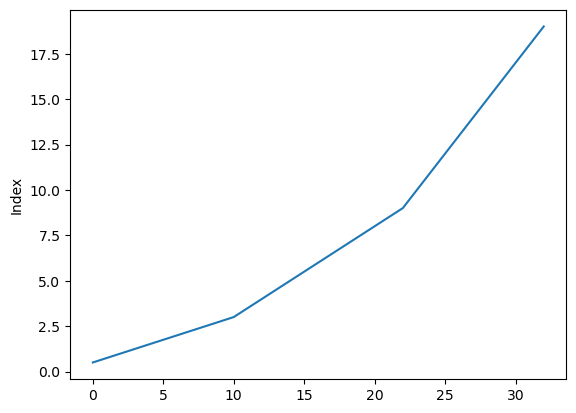

In [14]:
#########################
#LIST AVAILABLE DATA
def ListAllMRMSProducts(region="CONUS"):
    """
    Returns a list of all MRMS products available for a given region.
    """
    aws = s3fs.S3FileSystem(anon=True)

    # List directory
    products = aws.ls(f"noaa-mrms-pds/{region}/")
    products = [p.split("/")[-1] for p in products]
    return products

def SearchMRMSProducts(key, region="CONUS"):
    """
    Returns all MRMS products whose names contain the given key.
    """
    all_products = ListAllMRMSProducts(region)
    matches = [p for p in all_products if key in p]
    return matches



# all_products = ListAllMRMSProducts("CONUS")
# print(all_products)

matches = SearchMRMSProducts("MergedReflectivityQC_", "CONUS")
print(matches)


levels = [match[21:] for match in matches]
levels = [float(level) for level in levels]
print(levels)
plt.plot(levels); plt.ylabel("Altitude (km)"); plt.ylabel("Index")

In [15]:
########################
#DATA RETRIEVAL

In [ ]:
# ============================================================
# Main Loop: Load multiple dates
# ============================================================
region_options = [
    "CONUS",
    "ALASKA",
    "CARIB",
    "GUAM",
    "HAWAII"
]

#Getting List of Product Options
# https://data.ucar.edu/en/dataset/mrms-merged-base-reflectivity-quality-controlled-data
# https://data.eol.ucar.edu/dataset/577.002

# product_options = ["MergedReflectivityQC_01.00"]
product_options = matches

# Retrieve the user selection from 'Region' 
region = "CONUS" if ModelData.region=="TRACER" else "Hawaii"

# Retrieve the user selection from 'MRMS product'

simulationDates = ModelData.simulationDates
# simulationDates = ['2022-06-21', '2022-06-22', '2022-06-23', '2022-06-24'] #temporary for TRACER/DIURNAL

datestrings = [datestring.replace('-','') for datestring in simulationDates[:-1]]


for product in product_options:
    outputPath = os.path.join(DirectoryManager.dataDirectory,
             "Observation_Data/TRACER/MRMS_RadarData",
             f"{simulationDates[0]}_{simulationDates[-1]}",product)
    
    MRMSData = RetrieveMRMSRadarData_V2(ModelData,region,product,datestrings,
                                     interval_hours="15min",
                                     outputPath = outputPath)